In [ ]:
pip install opencv-python 

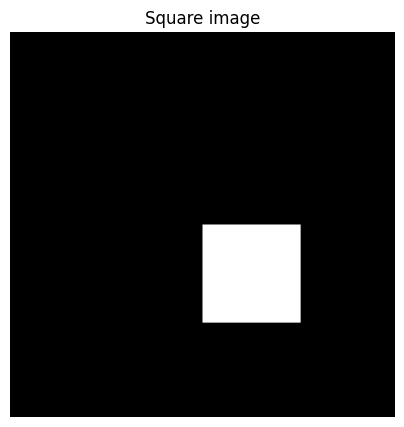

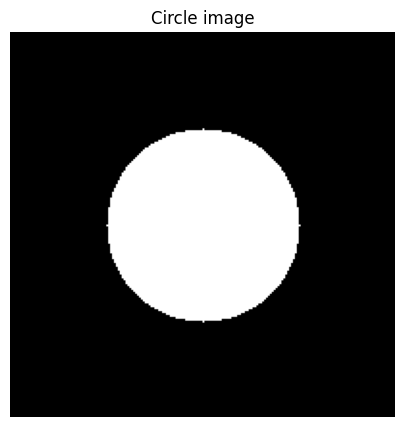

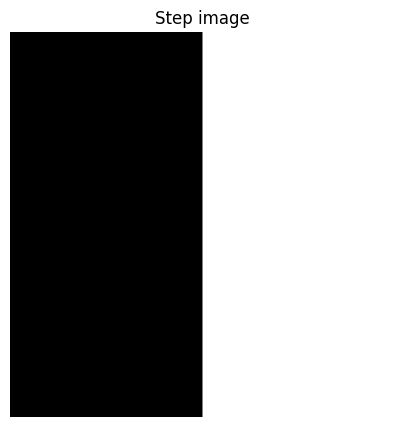

In [5]:
# Black background
img_square = np.zeros((200, 200), dtype=np.uint8)
img_circle = np.zeros((200, 200), dtype=np.uint8)
img_step = np.zeros((200, 200), dtype=np.uint8)

# Draw shapes (modify the rectangle coordinates here for the task)
cv2.rectangle(img_square, (100, 100), (150, 150), 255, -1)  # Changed position
cv2.circle(img_circle, (100, 100), 50, 255, -1)

# Create a step image: left side dark, right side bright
img_step[:, :100] = 50
img_step[:, 100:] = 220

show(img_square, "Square image")
show(img_circle, "Circle image")
show(img_step, "Step image")

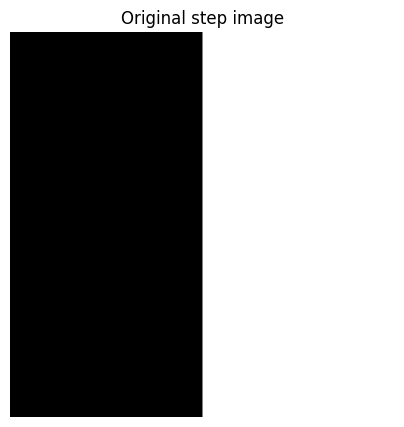

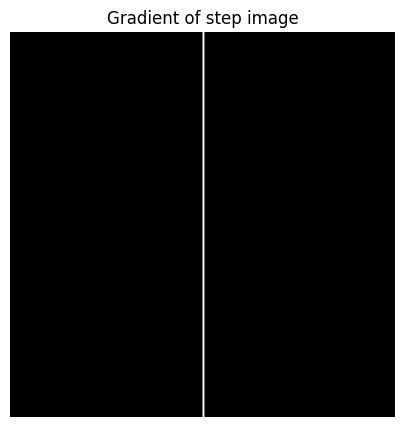

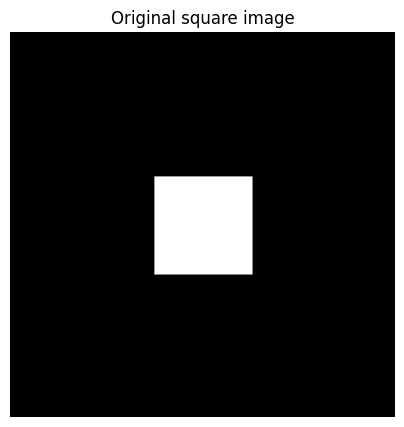

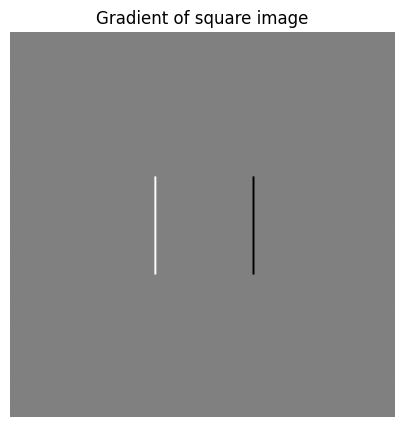

In [3]:
# Simple horizontal gradient kernel
kernel_x = np.array([[-1, 1]], dtype=np.float32)

grad_step = cv2.filter2D(img_step, cv2.CV_64F, kernel_x)
grad_square = cv2.filter2D(img_square, cv2.CV_64F, kernel_x)

show(img_step, "Original step image")
show(grad_step, "Gradient of step image")
show(img_square, "Original square image")
show(grad_square, "Gradient of square image")

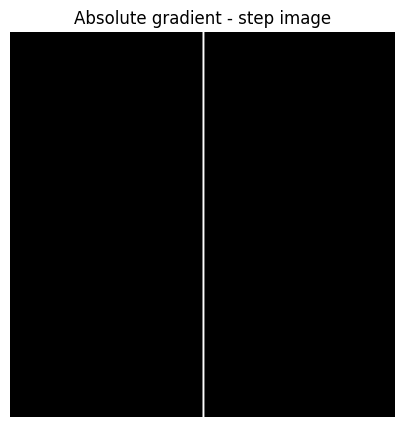

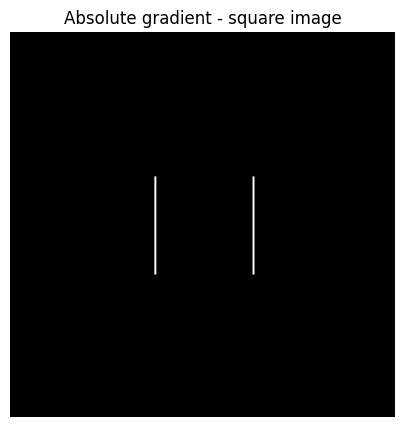

In [4]:
# Convert the gradient to absolute values for easier display
grad_square_abs = np.abs(grad_square).astype(np.uint8)
grad_step_abs = np.abs(grad_step).astype(np.uint8)

show(grad_step_abs, "Absolute gradient - step image")
show(grad_square_abs, "Absolute gradient - square image")

## 2. Topic 1 — Simple image gradients

### Main idea

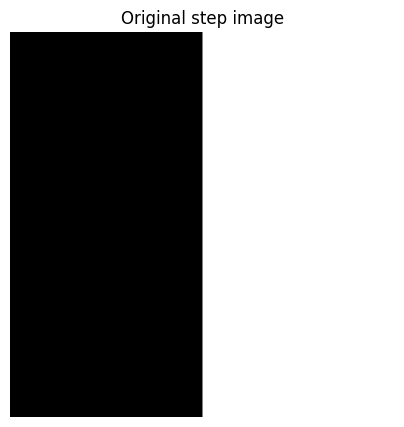

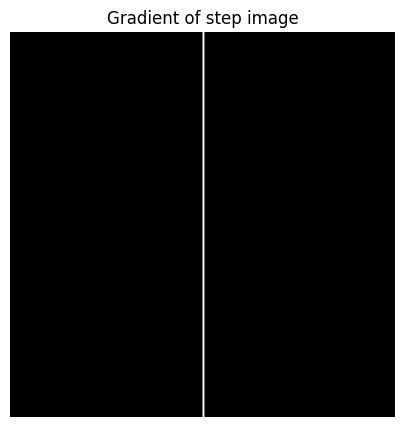

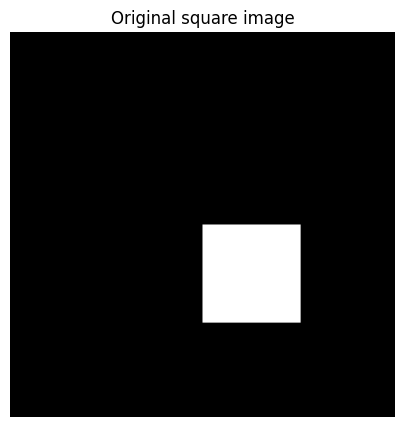

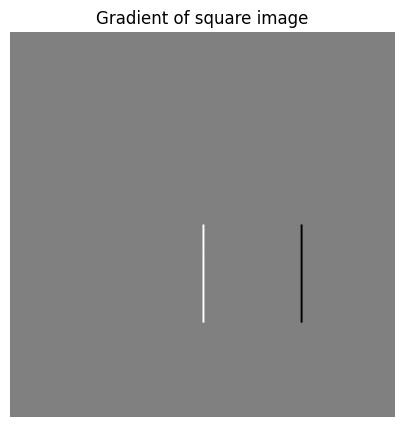

In [6]:
# Simple horizontal gradient kernel
kernel_x = np.array([[-1, 1]], dtype=np.float32)

grad_step = cv2.filter2D(img_step, cv2.CV_64F, kernel_x)
grad_square = cv2.filter2D(img_square, cv2.CV_64F, kernel_x)

show(img_step, "Original step image")
show(grad_step, "Gradient of step image")
show(img_square, "Original square image")
show(grad_square, "Gradient of square image")

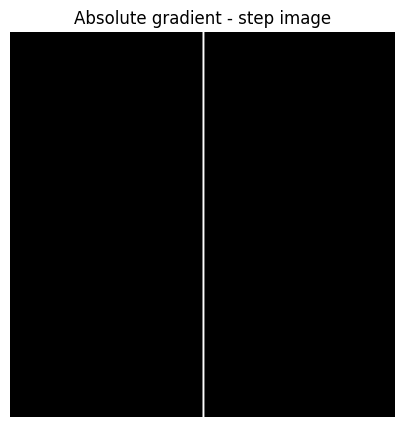

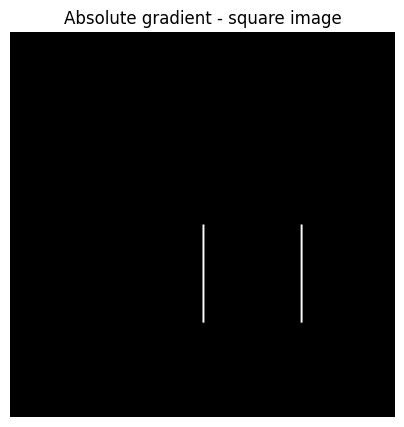

In [8]:
# Convert the gradient to absolute values for easier display
grad_square_abs = np.abs(grad_square).astype(np.uint8)
grad_step_abs = np.abs(grad_step).astype(np.uint8)

show(grad_step_abs, "Absolute gradient - step image")
show(grad_square_abs, "Absolute gradient - square image")

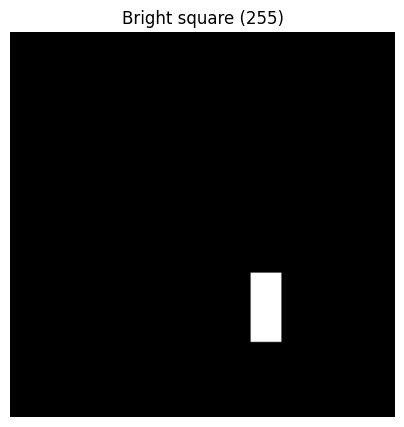

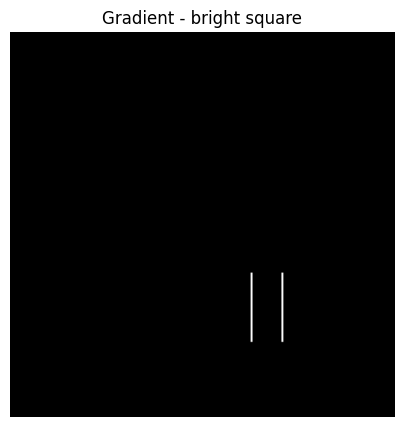

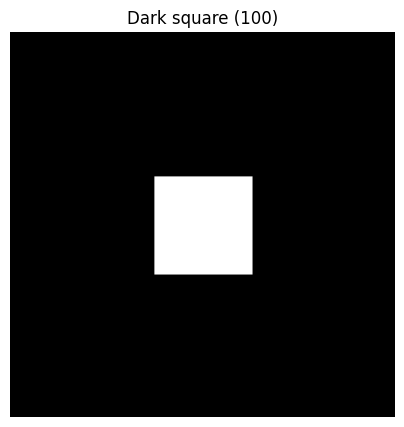

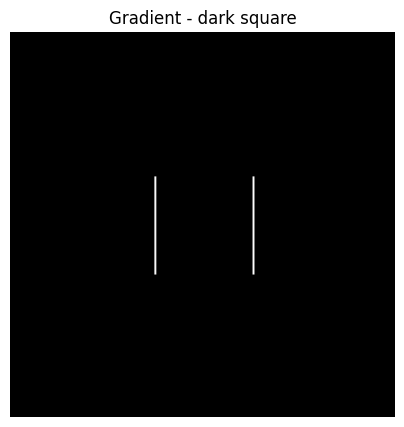

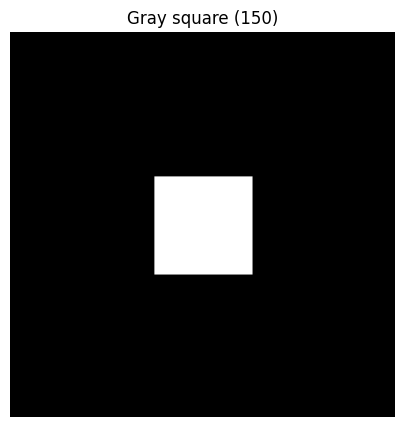

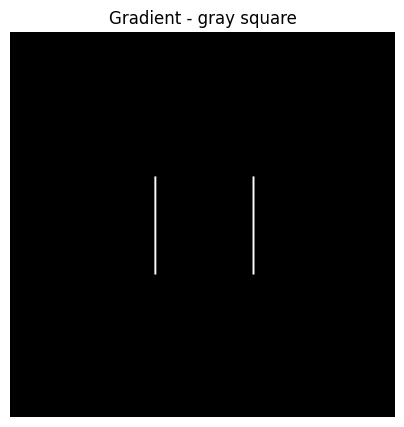

In [10]:
# Task 2: Create brighter/darker squares and compare gradient strength

# Create squares with different intensities
img_square_bright = np.zeros((200, 200), dtype=np.uint8)
img_square_dark = np.zeros((200, 200), dtype=np.uint8)
img_square_gray = np.zeros((200, 200), dtype=np.uint8)

# Bright square (full white, 255)
cv2.rectangle(img_square_bright, (140, 160), (125, 125), 255, -1)

# Dark square (dark gray, 100)
cv2.rectangle(img_square_dark, (75, 75), (125, 125), 100, -1)

# Gray square (medium gray, 150)
cv2.rectangle(img_square_gray, (75, 75), (125, 125), 150, -1)

# Apply gradient to each
grad_bright = cv2.filter2D(img_square_bright, cv2.CV_64F, kernel_x)
grad_dark = cv2.filter2D(img_square_dark, cv2.CV_64F, kernel_x)
grad_gray = cv2.filter2D(img_square_gray, cv2.CV_64F, kernel_x)

# Convert to absolute for display
grad_bright_abs = np.abs(grad_bright).astype(np.uint8)
grad_dark_abs = np.abs(grad_dark).astype(np.uint8)
grad_gray_abs = np.abs(grad_gray).astype(np.uint8)

# Display comparisons
show(img_square_bright, "Bright square (255)")
show(grad_bright_abs, "Gradient - bright square")

show(img_square_dark, "Dark square (100)")
show(grad_dark_abs, "Gradient - dark square")

show(img_square_gray, "Gray square (150)")
show(grad_gray_abs, "Gradient - gray square")

In [ ]:
def simple_gradient(image, direction='x'):
    if direction=='x':
        k = np.array([[-1,1]],np.float32)
    else:
        k = np.array([[-1],[1]],np.float32)
    return cv2.filter2D(image, cv2.CV_64F, k)

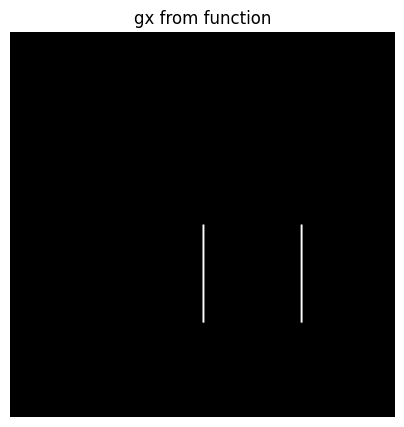

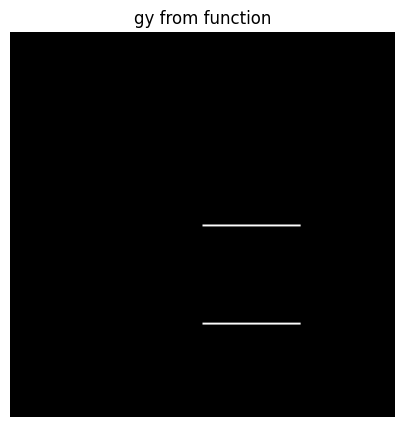

In [12]:
def simple_gradient(image, direction='x'):
    if direction=='x':
        k = np.array([[-1, 1]], np.float32)
    else:
        k = np.array([[-1], [1]], np.float32)
    return cv2.filter2D(image, cv2.CV_64F, k)

# test it quickly
gx = simple_gradient(img_square, 'x')
gy = simple_gradient(img_square, 'y')
show(np.abs(gx).astype(np.uint8), "gx from function")
show(np.abs(gy).astype(np.uint8), "gy from function")

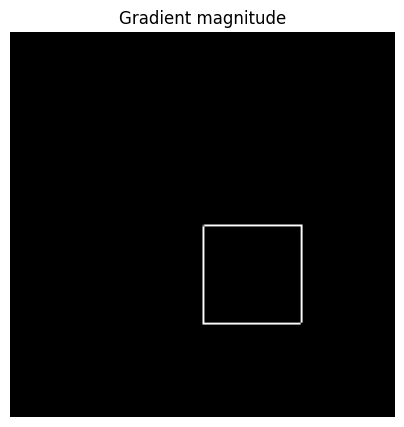

In [13]:
# Combine x and y gradients into magnitude
gx = simple_gradient(img_square, 'x')
gy = simple_gradient(img_square, 'y')
mag = np.sqrt(gx**2 + gy**2)
show(np.abs(mag).astype(np.uint8), "Gradient magnitude")

# This gives a more complete edge map because it detects edges in ALL directions,
# not just horizontal (gx) or vertical (gy). The magnitude combines both responses.

In [ ]:
## Explanation of Edges and Gradients

An **edge** is a boundary in an image where the intensity (brightness) changes suddenly and significantly, often marking the outline of objects or regions with different properties.

**Gradients detect edges** because they measure the rate of change in intensity across neighboring pixels. A high gradient value indicates a steep intensity transition, which corresponds to an edge location.

We use **absolute values for display** because gradient kernels can produce both positive and negative results depending on the direction of the change (e.g., from dark to light vs. light to dark). Taking the absolute value ensures all edges appear as bright areas in the output image, regardless of the transition direction.

## 3. Topic 2 — Sobel operator

### Main idea

The Sobel operator is a more sophisticated way to detect edges.

- It uses a **3x3 kernel** instead of a simple 1x2 or 2x1.
- It computes gradients in both x and y directions simultaneously.
- It includes **smoothing** to reduce noise sensitivity.

### How it works

The Sobel x-kernel is:

```
[-1, 0, 1]
[-2, 0, 2]
[-1, 0, 1]
```

The y-kernel is the transpose:

```
[-1, -2, -1]
[ 0,  0,  0]
[ 1,  2,  1]
```

Then, the gradient magnitude is computed as `sqrt(gx^2 + gy^2)`.

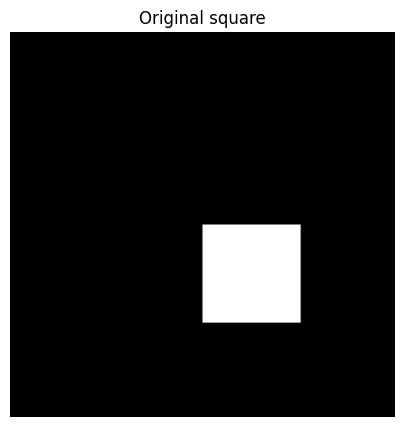

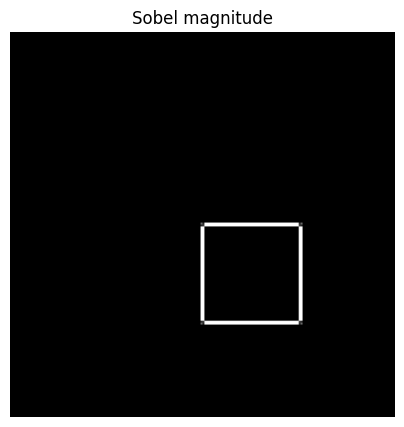

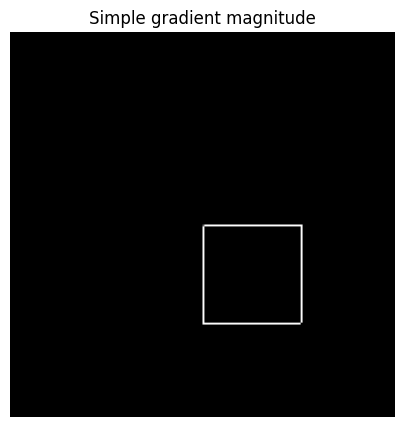

In [14]:
# Basic task 1: Apply Sobel to the square image and compare with simple gradient

# Sobel gradients
sobel_gx = cv2.Sobel(img_square, cv2.CV_64F, 1, 0, ksize=3)
sobel_gy = cv2.Sobel(img_square, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = np.sqrt(sobel_gx**2 + sobel_gy**2)

# Simple gradient for comparison
simple_gx = simple_gradient(img_square, 'x')
simple_gy = simple_gradient(img_square, 'y')
simple_mag = np.sqrt(simple_gx**2 + simple_gy**2)

# Display
show(img_square, "Original square")
show(np.abs(sobel_mag).astype(np.uint8), "Sobel magnitude")
show(np.abs(simple_mag).astype(np.uint8), "Simple gradient magnitude")

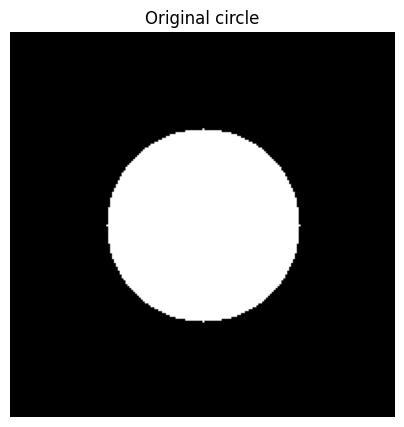

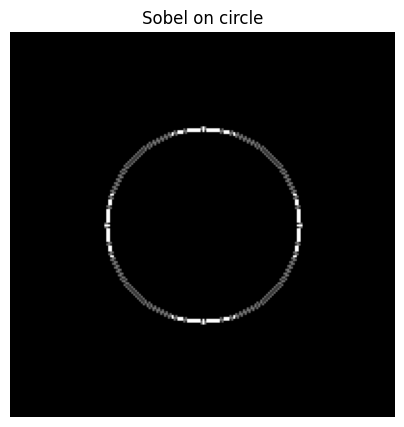

In [15]:
# Basic task 2: Apply Sobel to the circle image

sobel_gx_circle = cv2.Sobel(img_circle, cv2.CV_64F, 1, 0, ksize=3)
sobel_gy_circle = cv2.Sobel(img_circle, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag_circle = np.sqrt(sobel_gx_circle**2 + sobel_gy_circle**2)

show(img_circle, "Original circle")
show(np.abs(sobel_mag_circle).astype(np.uint8), "Sobel on circle")

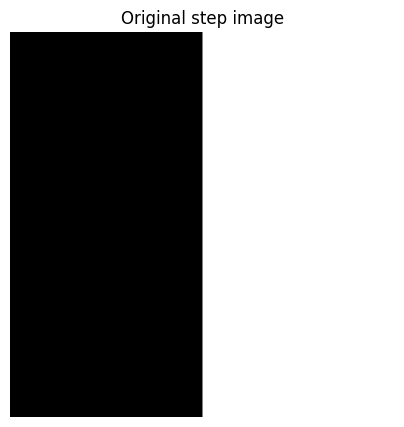

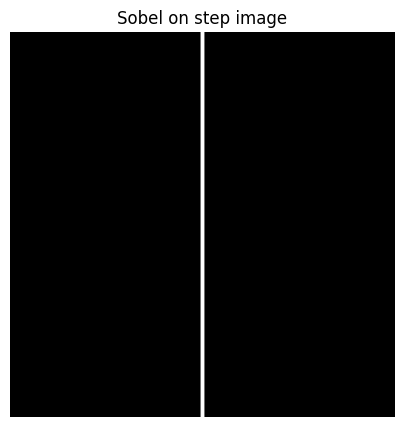

In [16]:
# Basic task 3: Apply Sobel to the step image

sobel_gx_step = cv2.Sobel(img_step, cv2.CV_64F, 1, 0, ksize=3)
sobel_gy_step = cv2.Sobel(img_step, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag_step = np.sqrt(sobel_gx_step**2 + sobel_gy_step**2)

show(img_step, "Original step image")
show(np.abs(sobel_mag_step).astype(np.uint8), "Sobel on step image")

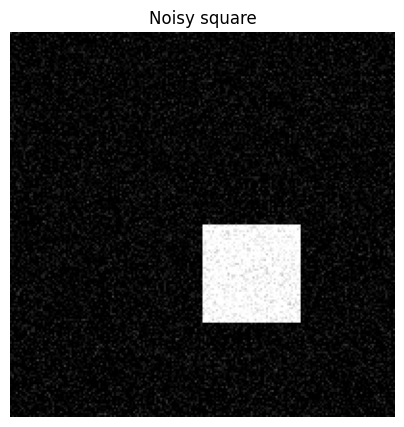

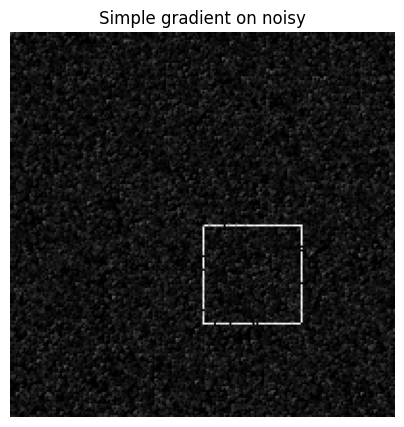

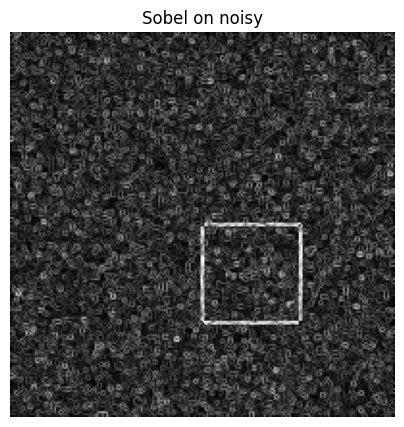

In [ ]:
# Intermediate tasks 4-5: Compare noise robustness

# Add Gaussian noise to square
noisy_square = img_square + np.random.normal(0, 20, img_square.shape).astype(np.int16)
noisy_square = np.clip(noisy_square, 0, 255).astype(np.uint8)

# Simple gradient on noisy
simple_gx_noisy = simple_gradient(noisy_square, 'x')
simple_gy_noisy = simple_gradient(noisy_square, 'y')
simple_mag_noisy = np.sqrt(simple_gx_noisy**2 + simple_gy_noisy**2)

# Sobel on noisy
sobel_gx_noisy = cv2.Sobel(noisy_square, cv2.CV_64F, 1, 0, ksize=3)
sobel_gy_noisy = cv2.Sobel(noisy_square, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag_noisy = np.sqrt(sobel_gx_noisy**2 + sobel_gy_noisy**2)
# Display results 
show(noisy_square, "Noisy square")
show(np.abs(simple_mag_noisy).astype(np.uint8), "Simple gradient on noisy")
show(np.abs(sobel_mag_noisy).astype(np.uint8), "Sobel on noisy")

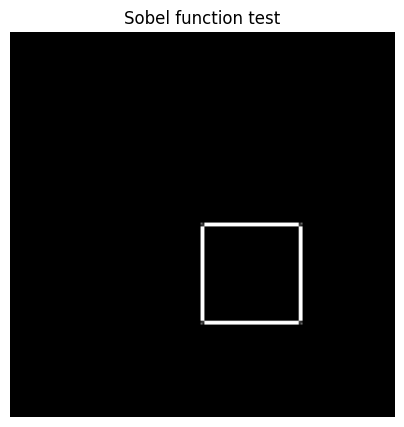

In [18]:

# Challenging task 6: Create sobel_edges function

def sobel_edges(image, ksize=3):
    gx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=ksize)
    gy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=ksize)
    mag = np.sqrt(gx**2 + gy**2)
    return gx, gy, mag

# Test it
gx_test, gy_test, mag_test = sobel_edges(img_square)
show(np.abs(mag_test).astype(np.uint8), "Sobel function test")

Image | Max Magnitude | Mean Magnitude
------|---------------|---------------
Square | 1081.87 | 10.30
Circle | 1140.39 | 16.32
Step | 680.00 | 6.80


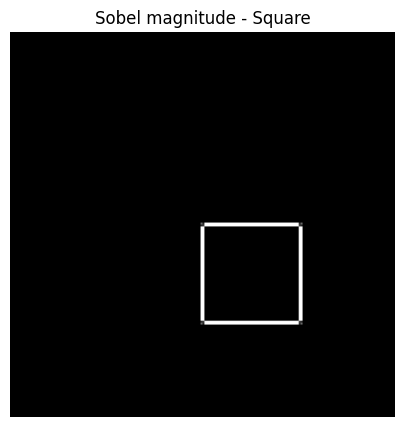

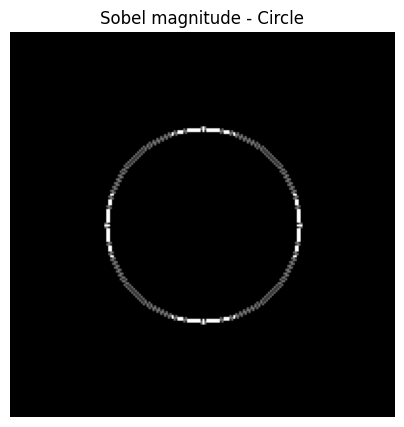

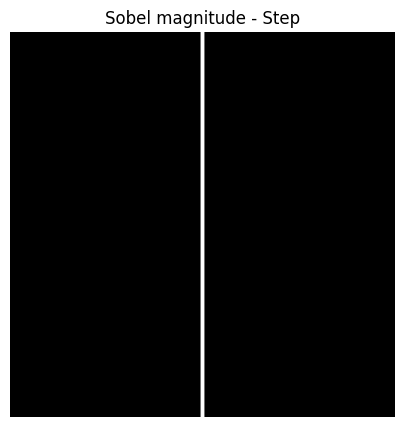

In [19]:
# Challenging task 7: Use function on three images and compare

images = [img_square, img_circle, img_step]
names = ["Square", "Circle", "Step"]

print("Image | Max Magnitude | Mean Magnitude")
print("------|---------------|---------------")
for img, name in zip(images, names):
    _, _, mag = sobel_edges(img)
    max_mag = np.max(mag)
    mean_mag = np.mean(mag)
    print(f"{name} | {max_mag:.2f} | {mean_mag:.2f}")

# Show the magnitudes
for img, name in zip(images, names):
    _, _, mag = sobel_edges(img)
    show(np.abs(mag).astype(np.uint8), f"Sobel magnitude - {name}")

## Challenging task 8: Why Sobel is preferred over basic gradient

Sobel is often preferred over a very basic gradient kernel because:

- **Noise reduction**: The 3x3 Sobel kernel includes smoothing (weighted averaging) which reduces the impact of random noise in the image, making edge detection more reliable.
- **Better edge localization**: The larger kernel provides more accurate edge positioning compared to simple 1x2 kernels.
- **Directionality**: Sobel computes both x and y gradients simultaneously, allowing for magnitude calculation that detects edges in any orientation.
- **Standardization**: It's a well-established method with predictable behavior across different images.

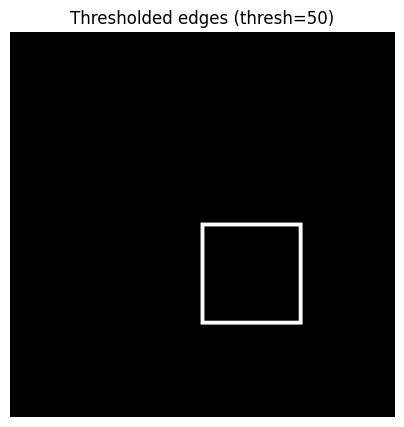

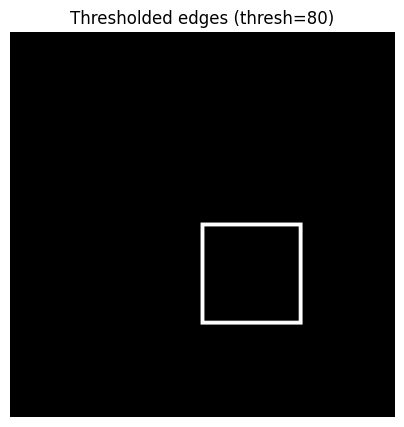

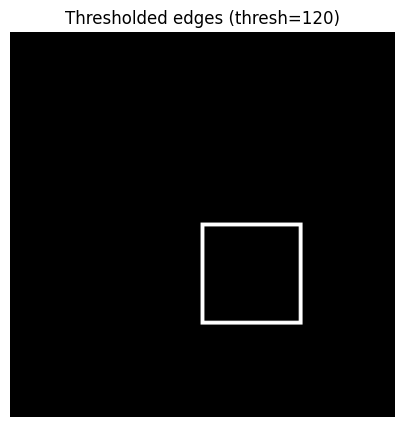

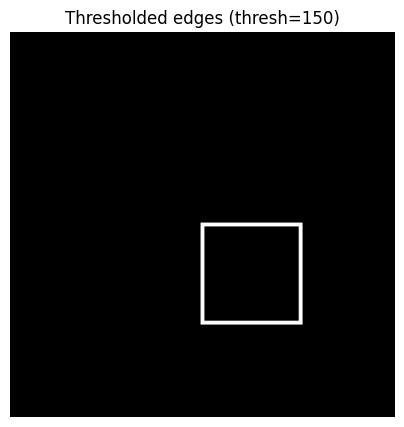

In [20]:
# Challenging task 9: Threshold Sobel magnitude

_, _, mag = sobel_edges(img_square)

thresholds = [50, 80, 120, 150]

for thresh in thresholds:
    binary = (mag > thresh).astype(np.uint8) * 255
    show(binary, f"Thresholded edges (thresh={thresh})")

# Best threshold: Around 80-120 seems good - captures main edges without too much noise